In [1]:
import pandas as pd
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

# -----------------------------
# LOAD DATA
# -----------------------------
data = pd.read_csv('2-production_history.txt', sep="\t")  # read dataset

Initial Rate (q1): 13642.51 STB/day
Decline Rate (Di): 0.0325
b-factor: 1.02
Estimated Ultimate Recovery (EUR): 1573777.27 STB


C:\Users\HP\AppData\Local\Temp\ipykernel_13764\577712828.py:78: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  eur = np.trapz(future_rate, future_time) + df_well['Cum_Oil'].iloc[-1]


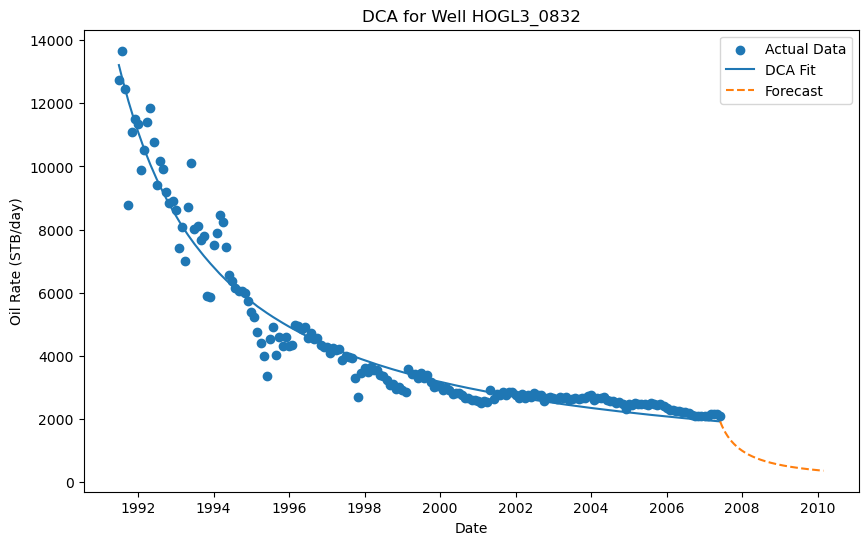

In [6]:
# Select a specific well
well = 'HOGL3_0832'
df_well = data[data['UID'] == well].copy()  # filter data for one well

# -----------------------------
# DATA PREPARATION
# -----------------------------
df_well['Date'] = pd.to_datetime(df_well['Date'])  # convert Date column to datetime

# Filter data to remove early noisy production (common in DCA)
df_well = df_well[df_well['Date'] > '1991-06-01']

# Sort data by date (important for time series)
df_well = df_well.sort_values('Date')

# Reset index after filtering
df_well = df_well.reset_index(drop=True)

# Create a time variable (1, 2, 3, ...)
# This represents production time steps used in decline modelling
df_well['time'] = np.arange(1, len(df_well) + 1)

# Extract variables for modelling
time = df_well['time']          # time (independent variable)
oil_rate = df_well['OIL']       # oil production rate (dependent variable)

# -----------------------------
# DECLINE CURVE MODEL
# -----------------------------
# Hyperbolic decline model (most common in industry)
def dca(t, q1, b, Di):
    # q1 = initial production rate
    # b = decline curve shape factor
    # Di = initial decline rate
    return q1 / (1 + (b * Di * t))**(1 / b)

# -----------------------------
# CURVE FITTING
# -----------------------------
# Fit the model to historical data
# curve_fit finds the best q1, b, Di values
popt, _ = opt.curve_fit(dca, time, oil_rate, maxfev=10000)

# Extract fitted parameters
q1, b, Di = popt

# Print results for interpretation
print(f"Initial Rate (q1): {q1:.2f} STB/day")
print(f"Decline Rate (Di): {Di:.4f}")
print(f"b-factor: {b:.2f}")

# -----------------------------
# MODEL PREDICTION
# -----------------------------
# Calculate fitted values using the model
pred_rate = dca(time, q1, b, Di)

# -----------------------------
# FORECASTING (FUTURE PRODUCTION)
# -----------------------------
# Extend time beyond historical data
future_time = np.arange(time.max(), time.max() + 1000)

# Predict future oil rates
future_rate = dca(future_time, q1, b, Di)

# -----------------------------
# CUMULATIVE PRODUCTION
# -----------------------------
# Calculate cumulative oil produced so far
df_well['Cum_Oil'] = df_well['OIL'].cumsum()

# -----------------------------
# ESTIMATED ULTIMATE RECOVERY (EUR)
# -----------------------------
# Integrate future production + current cumulative production
# np.trapz approximates area under the curve (total production)
eur = np.trapz(future_rate, future_time) + df_well['Cum_Oil'].iloc[-1]

print(f"Estimated Ultimate Recovery (EUR): {eur:.2f} STB")

# -----------------------------
# PLOTTING
# -----------------------------
plt.figure(figsize=(10, 6))

# Plot actual production data
plt.scatter(df_well['Date'], oil_rate, label='Actual Data')

# Plot model fit (history match)
plt.plot(df_well['Date'], pred_rate, label='DCA Fit')

# Create future dates for plotting forecast
future_dates = pd.date_range(start=df_well['Date'].iloc[-1], periods=1000)

# Plot forecasted production
plt.plot(future_dates, future_rate, linestyle='--', label='Forecast')

# Labels and title
plt.xlabel("Date")
plt.ylabel("Oil Rate (STB/day)")
plt.title(f"DCA for Well {well}")

# Show legend
plt.legend()

# Display plot
plt.show()

